4M17 coursework exercise

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import importlib, newton
importlib.reload(newton)
from newton import newton, newton_barrier_eq, newton_barrier_phase1


In [35]:
#Task 1(a)
def f_0(x0 : list) -> list:
    x = np.array(x0)
    return np.log(np.linalg.norm(np.exp(x), ord=1)) + 0.5*np.linalg.norm(x)**2

def grad_f_0(x0 : list) -> list:
    x = np.array(x0)
    return np.exp(x)/np.linalg.norm(np.exp(x), ord=1) + x

def hess_f_0(x0 : list) -> list:
    x = np.array(x0)
    d = (np.linalg.norm(np.exp(x), ord=1))
    return np.eye(2) + (np.diag(np.exp(x)))/d - (np.outer(np.exp(x), np.exp(x)))/(d**2)

Will include the hand-calculated working out here, after using word's ink-to-math and then copying the latex code into this mark down, or keeping the working in word.

In [36]:
#Task 1(b)
x_0 = np.array([-1.5, 2.5]) #given in the question
x_star, num_iters, path = newton(x_0, f_0, grad_f_0, hess_f_0, eps=1e-6) #modified newton to return intermediate steps
print("x* =", x_star)


x* = [-0.49999952 -0.50000048]


In [37]:
assert len(path) == num_iters + 1 #checks path is the right size

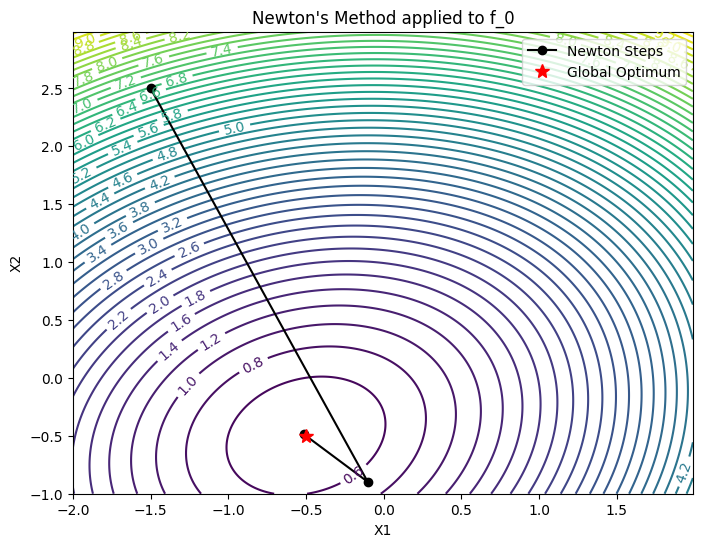

In [38]:
x1 = np.arange(-2,2,0.01)
x2 = np.arange(-1,3,0.01)
X1, X2 = np.meshgrid(x1, x2)
map = np.array([f_0([a, b]) for a, b in zip(X1.ravel(), X2.ravel())]).reshape(X1.shape)
fig = plt.figure(figsize=(8,6))
contours = plt.contour(X1, X2, map, levels=50, cmap='viridis')
plt.clabel(contours)

#ax = fig.add_subplot(111, projection='3d')
#ax.plot_surface(X1, X2, map, cmap='viridis', alpha=0.8)

path = np.array(path)
plt.plot(path[:-1,0], path[:-1,1], 'ko-', label='Newton Steps')
plt.plot(path[-1,0], path[-1,1],'r*', label='Global Optimum', markersize=10)
plt.legend(loc='upper right')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Newton\'s Method applied to f_0')
plt.show()

In [39]:
#Task 1(c)
A = np.array([[0.5, 1]])
b = np.array([1])
x_0 = np.linalg.lstsq(A,b, rcond=None)[0] #finds least squares solution to Ax=b to use as starting point
x_star, num_iters, path = newton(x_0, f_0, grad_f_0, hess_f_0, A = A, b = b)
print("x* with constraint =", x_star)
#print(num_iters)
#print(path)

x* with constraint = [0.34305302 0.82847349]


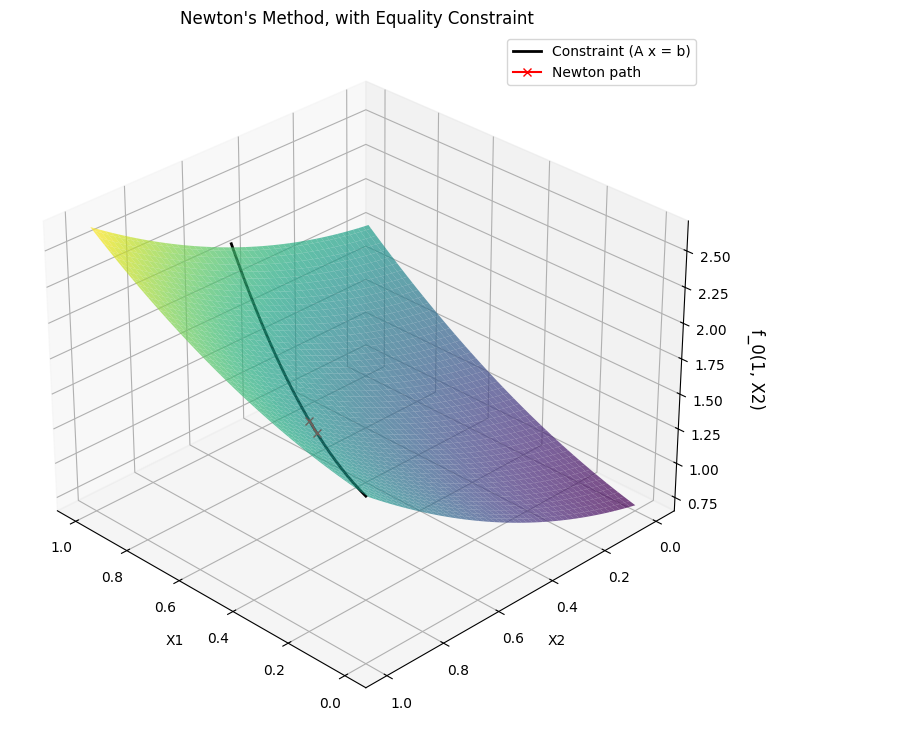

In [40]:
# Plot f_0 surface
x1 = np.arange(0, 1, 0.01)
x2 = np.arange(0, 1, 0.01)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([f_0([a, b]) for a, b in zip(X1.ravel(), X2.ravel())]).reshape(X1.shape)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)

# Plot constraint surface
if A.shape == (1, 2):  # single linear constraint in 2D
    a1, a2 = A[0]
    x1_line = np.linspace(0, 1, 100)
    x2_line = (b - a1 * x1_line) / a2
    mask = (x2_line >= 0) & (x2_line <= 1)
    x1_line = x1_line[mask]
    x2_line = x2_line[mask]
    z_line = np.array([f_0([x, y]) for x, y in zip(x1_line, x2_line)])
    ax.plot(x1_line, x2_line, z_line, color='black', label='Constraint (A x = b)', linewidth=2)
else:
    print("Skipping constraint plot: only implemented for one equality constraint in 2D.")

ax.plot(
    path[:,0], path[:,1],
    [f_0(p) for p in path],
    color='r', marker='x', label='Newton path'
)


ax.set_xlabel('X1')
ax.set_ylabel('X2')

# Place z-label on the right-hand side and rotate vertically
try:
    ax.zaxis.set_rotate_label(False)
    # Set the z-label and rotate it so it reads vertically on the right
    ax.set_zlabel('f_0(1, X2)', labelpad=10, fontsize=12)
    # rotate the label text and position it just outside the axes to the right
    ax.zaxis.label.set_rotation(270)
    ax.zaxis.set_label_coords(1.05, 0.5)
except Exception:
    # Fallback: place label with larger pad (some backends ignore rotation settings)
    ax.set_zlabel('f_0(X1, X2)', labelpad=25, fontsize=12)

ax.view_init(elev=30, azim=135)
ax.set_title("Newton's Method, with Equality Constraint")
ax.legend()

# Increase right margin so vertical z-label has space
fig.subplots_adjust(top=0.88, right=0.88)
# Robust fallback: some backends ignore mplot3d z-axis label rotation/coords.
# Draw a rotated z-label at the right-hand figure margin so it is always visible.
fig.text(0.95, 0.5, ' ', va='center', ha='center', rotation=270, fontsize=12)
plt.show()


In [41]:
#Task 1(d) - Define inequality constraints
# f_i(x) <= 0 for i = 1, 2, 3

def h(x):
    """Inequality constraints h_i(x) <= 0"""
    f1 = x[0] + x[1] - 1.5
    f2 = -0.25*x[0] + x[1] - 2
    f3 = -0.1*x[0] - x[1] + 1
    return np.array([f1, f2, f3])

def grad_h(x):
    """Gradient of constraint functions: shape (3, 2)"""
    return np.array([[1.0, 1.0],
                     [-0.25, 1.0],
                     [-0.1, -1.0]])

def hess_h(x):
    """Hessian of each constraint (linear constraints have zero Hessian)"""
    return [np.zeros((2, 2)), np.zeros((2, 2)), np.zeros((2, 2))]

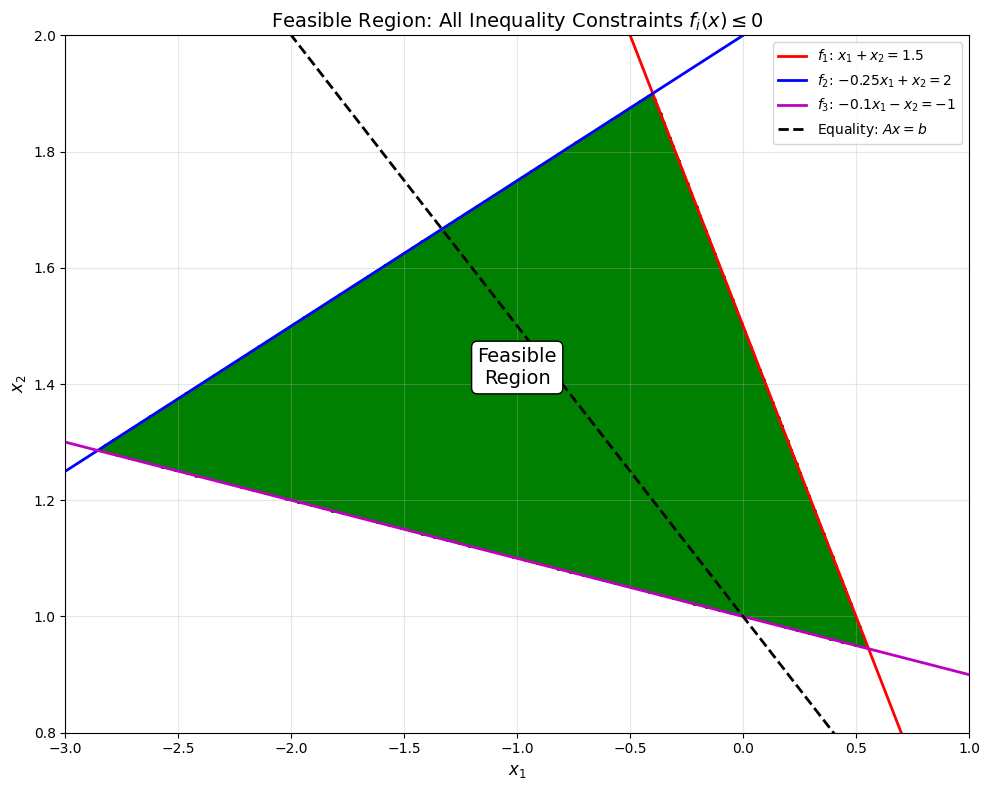

In [42]:
# Visualize the feasible region defined by inequality constraints h(x) <= 0

# Create grid
x1 = np.linspace(-3, 1, 300)
x2 = np.linspace(0.5, 2, 300)
X1, X2 = np.meshgrid(x1, x2)

# Vectorized evaluation: reshape grid to (N*M, 2), evaluate h, reshape back
points = np.stack([X1.ravel(), X2.ravel()], axis=1)
H_all = np.array([h(pt) for pt in points])  # Shape: (N*M, 3)

# Reshape to (N, M, 3) for each constraint
H = H_all.reshape(X1.shape[0], X1.shape[1], 3)

# Feasible region: all constraints satisfied (all h_i <= 0)
feasible = np.all(H <= 0, axis=2)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the feasible region in green
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], colors=['green'], alpha=1)

# Plot constraint boundaries
# f1: x1 + x2 = 1.5
x1_line = np.linspace(-3, 3, 100)
ax.plot(x1_line, 1.5 - x1_line, 'r-', linewidth=2, label='$f_1$: $x_1 + x_2 = 1.5$')

# f2: -0.25*x1 + x2 = 2
ax.plot(x1_line, 2 + 0.25*x1_line, 'b-', linewidth=2, label='$f_2$: $-0.25x_1 + x_2 = 2$')

# f3: -0.1*x1 - x2 = -1  =>  x2 = 1 - 0.1*x1
ax.plot(x1_line, 1 - 0.1*x1_line, 'm-', linewidth=2, label='$f_3$: $-0.1x_1 - x_2 = -1$')

# Add equality constraint Ax = b for reference
if 'A' in globals() and 'b' in globals():
    x2_eq = (b[0] - A[0, 0] * x1_line) / A[0, 1]
    ax.plot(x1_line, x2_eq, 'k--', linewidth=2, label='Equality: $Ax = b$', alpha=1)

# Add annotation in feasible region
ax.text(-1, 1.4, 'Feasible\nRegion', fontsize=14, ha='center', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=1))

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Feasible Region: All Inequality Constraints $f_i(x) \\leq 0$', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 1)
ax.set_ylim(0.8, 2)
plt.tight_layout()
plt.show()

PHASE I: Finding strictly feasible starting point (via newton_barrier_phase1)
Phase I completed in 2 iterations
Strictly feasible starting point found: x_init = [-0.79716488  1.39858244]
Constraint values h(x_init) = [-0.89858244 -0.40212634 -0.31886595]
Equality constraint Ax - b = [-2.22044605e-16]

✓ Phase I successful: Found strictly feasible starting point


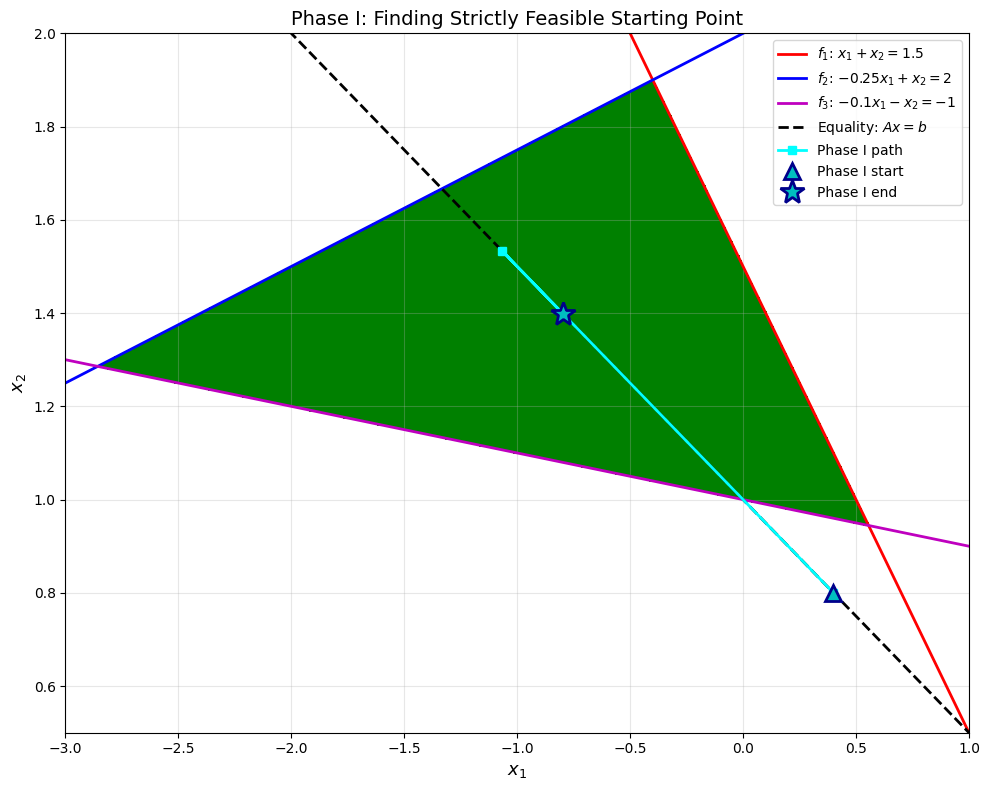

In [43]:
#Task 1(e) - PHASE I: Find strictly feasible starting point

print("="*60)
print("PHASE I: Finding strictly feasible starting point (via newton_barrier_phase1)")
print("="*60)

# Compute Phase I using the dedicated helper in newton.py
x_init, iters_phase1, path_phase1 = newton_barrier_phase1(
    np.linalg.lstsq(A, b, rcond=None)[0],
    h, grad_h, hess_h,
    A=A, b=b,
    t_0=1.0, mu=10.0, eps=1e-6,
    max_outer=30, max_inner=50,
    early_tol=-1e-6
)

print(f"Phase I completed in {iters_phase1} iterations")
print(f"Strictly feasible starting point found: x_init = {x_init}")
print(f"Constraint values h(x_init) = {h(x_init)}")
print(f"Equality constraint Ax - b = {A @ x_init - b}")
print("\n✓ Phase I successful: Found strictly feasible starting point")
print("="*60)

# Visualize Phase I path
fig, ax = plt.subplots(figsize=(10, 8))

# Create grid and identify feasible region
x1_plot = np.linspace(-3, 1, 400)
x2_plot = np.linspace(0.5, 2, 400)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
points = np.stack([X1.ravel(), X2.ravel()], axis=1)
H_all = np.array([h(pt) for pt in points])
H_grid = H_all.reshape(X1.shape[0], X1.shape[1], 3)
feasible = np.all(H_grid <= 0, axis=2)

# Plot feasible region
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], colors=['green'], alpha=1)

# Plot inequality constraint boundaries
x1_line = np.linspace(-3, 3, 100)
ax.plot(x1_line, 1.5 - x1_line, 'r-', linewidth=2, label='$f_1$: $x_1 + x_2 = 1.5$')
ax.plot(x1_line, 2 + 0.25*x1_line, 'b-', linewidth=2, label='$f_2$: $-0.25x_1 + x_2 = 2$')
ax.plot(x1_line, 1 - 0.1*x1_line, 'm-', linewidth=2, label='$f_3$: $-0.1x_1 - x_2 = -1$')

# Plot equality constraint Ax = b
x2_eq = (b[0] - A[0, 0] * x1_line) / A[0, 1]
ax.plot(x1_line, x2_eq, 'k--', linewidth=2, label='Equality: $Ax = b$', alpha=1)

# Ensure path_phase1 matches reported outer iterations (truncate if necessary)
if path_phase1 is not None:
    path_phase1 = np.array(path_phase1)
    try:
        max_points = int(iters_phase1) + 1
    except Exception:
        max_points = path_phase1.shape[0]
    if path_phase1.ndim == 2 and path_phase1.shape[0] > max_points:
        path_phase1 = path_phase1[:max_points]
    if path_phase1 is not None and path_phase1.size > 0:
        phase1_x = path_phase1[:, :-1]
        ax.plot(phase1_x[:, 0], phase1_x[:, 1], 'cyan', marker='s', markersize=6, linewidth=2, label='Phase I path', zorder=4)

# Plot Phase I starting and ending points
x0_eq = np.linalg.lstsq(A, b, rcond=None)[0]
ax.plot(x0_eq[0], x0_eq[1], 'c^', markersize=12, label='Phase I start', zorder=6, markeredgecolor='darkblue', markeredgewidth=2)
ax.plot(x_init[0], x_init[1], 'c*', markersize=18, label='Phase I end', zorder=6, markeredgecolor='darkblue', markeredgewidth=2)

ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Phase I: Finding Strictly Feasible Starting Point', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 1)
ax.set_ylim(0.5, 2)
plt.tight_layout()
plt.show()

PHASE II: Solving main optimisation problem
Phase II completed in 7 outer iterations
Constrained optimal solution: x* = [-3.07065458e-07  1.00000015e+00]
Optimal value: f_0(x*) = 1.813262
Constraint values h(x*) = [-5.00000154e-01 -9.99999770e-01 -1.22826183e-07]
Equality constraint Ax - b = [-2.22044605e-16]

✓ Phase II successful: Found constrained optimum


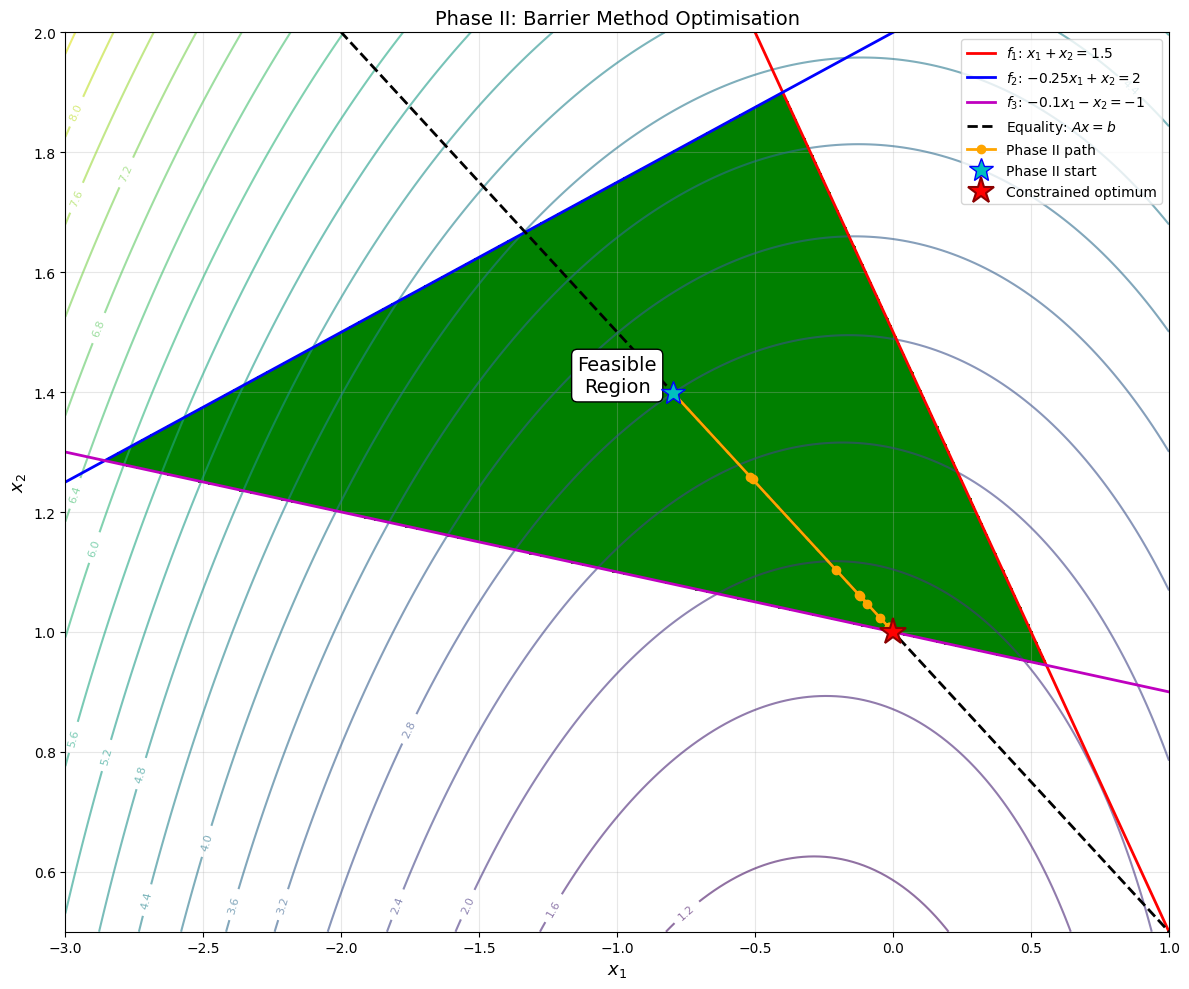

In [44]:
#Task 1(e) - PHASE II: Solve main optimisation problem

print("="*60)
print("PHASE II: Solving main optimisation problem")
print("="*60)

# PHASE II: Solve the main problem starting from feasible point
# Minimize f_0(x) subject to h(x) <= 0 and Ax = b
x_star_constrained, num_outer_iters, barrier_path = newton_barrier_eq(
    x_init, f_0, grad_f_0, hess_f_0,
    h, grad_h, hess_h,
    A=A, b=b,
    t_0=1.0, mu=10.0, eps=1e-6,
    max_outer=30, max_inner=50
)

print(f"Phase II completed in {num_outer_iters} outer iterations")
print(f"Constrained optimal solution: x* = {x_star_constrained}")
print(f"Optimal value: f_0(x*) = {f_0(x_star_constrained):.6f}")
print(f"Constraint values h(x*) = {h(x_star_constrained)}")
print(f"Equality constraint Ax - b = {A @ x_star_constrained - b}")
print("\n✓ Phase II successful: Found constrained optimum")
print("="*60)

# Visualize Phase II path
fig, ax = plt.subplots(figsize=(12, 10))

# Create grid and identify feasible region
x1_plot = np.linspace(-3, 1, 400)
x2_plot = np.linspace(0.5, 2, 400)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
points = np.stack([X1.ravel(), X2.ravel()], axis=1)
H_all = np.array([h(pt) for pt in points])
H_grid = H_all.reshape(X1.shape[0], X1.shape[1], 3)
feasible = np.all(H_grid <= 0, axis=2)

# Plot feasible region
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], colors=['green'], alpha=1)

# Create contours of f_0
x1_contour = np.linspace(-3, 1, 200)
x2_contour = np.linspace(0.5, 2, 200)
X1_c, X2_c = np.meshgrid(x1_contour, x2_contour)
Z = np.array([f_0([a, b]) for a, b in zip(X1_c.ravel(), X2_c.ravel())]).reshape(X1_c.shape)
contours = ax.contour(X1_c, X2_c, Z, levels=20, cmap='viridis', alpha=0.6)
ax.clabel(contours, inline=True, fontsize=8)

# Plot inequality constraint boundaries
x1_line = np.linspace(-3, 3, 100)
ax.plot(x1_line, 1.5 - x1_line, 'r-', linewidth=2, label='$f_1$: $x_1 + x_2 = 1.5$')
ax.plot(x1_line, 2 + 0.25*x1_line, 'b-', linewidth=2, label='$f_2$: $-0.25x_1 + x_2 = 2$')
ax.plot(x1_line, 1 - 0.1*x1_line, 'm-', linewidth=2, label='$f_3$: $-0.1x_1 - x_2 = -1$')

# Plot equality constraint Ax = b
x2_eq = (b[0] - A[0, 0] * x1_line) / A[0, 1]
ax.plot(x1_line, x2_eq, 'k--', linewidth=2, label='Equality: $Ax = b$', alpha=1)

# Plot Phase II (barrier method) path
if len(barrier_path) > 1:
    ax.plot(barrier_path[:, 0], barrier_path[:, 1], 'orange', marker='o', markersize=6, 
            linewidth=2, label='Phase II path', zorder=5)

# Plot Phase II starting point (from Phase I)
ax.plot(x_init[0], x_init[1], 'c*', markersize=18, label='Phase II start', zorder=6, 
        markeredgecolor='blue', markeredgewidth=1)

# Plot constrained optimum
ax.plot(x_star_constrained[0], x_star_constrained[1], 'r*', markersize=20, 
        label='Constrained optimum', zorder=7, markeredgecolor='darkred', markeredgewidth=1.5)

# Add annotation in feasible region
ax.text(-1, 1.4, 'Feasible\nRegion', fontsize=14, ha='center', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=1))

ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Phase II: Barrier Method Optimisation', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 1)
ax.set_ylim(0.5, 2)
plt.tight_layout()
plt.show()